# Облачные шаги: hybrid OCR и VLM-судья на тесте

Пайплайн ходит в Yandex Cloud в двух местах распознавания (третье — сомелье `/sommelier`, к
распознаванию не относится):

1. **OCR** (`ocr/recognize.py`). `WINE_OCR=hybrid`: сначала локальный PaddleOCR; кадр уходит в
   Yandex Vision, только если локальное чтение слабое — меньше 3 строк (`few_lines`) или лучшая
   строка неувереннее 0.6 (`low_conf`). Облачные строки заменяют локальные.
2. **VLM-судья** (`decide/judge.py`, `WINE_VLM=1`). Последний шаг после решающего слоя. Зовётся
   на спорных кадрах:
   - `refused_strong` — модель отказала, но у лидера ≥ 30 инлаеров XFeat;
   - `same_family` — лидер и второй кандидат из одной винодельни;
   - `margin` — разрыв вероятностей лидера и второго < 0.2.

   Судья видит кроп и до 8 карточек, выбирает номер (карточка поднимается наверх) или «ни одна»
   (с уверенностью ≥ 0.7 — отказ).

**Что включено в сервисе сейчас** (`.env`): `WINE_OCR=paddle`, `WINE_VLM=0` — ни облачный OCR,
ни судья в распознавании **не используются**. Этот ноутбук меряет, что дало бы их включение.

**Прогоны** — `eval/platform_benchmark.py` на `data/test` (живые кадры: ~93 знакомых, остальное —
незнакомые), индекс `index_platform_sq_v3`, решающий слой `decider_platform_sq_v3_slug`,
guard `warn`, продуктовый порог слоя:

| тег | OCR | судья |
|---|---|---|
| `cloud-07: ocr=paddle vlm=0` | PaddleOCR | нет |
| `cloud-07: ocr=hybrid vlm=0` | hybrid | нет |
| `cloud-07: ocr=hybrid vlm=1` | hybrid | Yandex AI Studio, `qwen3.6-35b-a3b` |

Тест — изолированный holdout: здесь только измерение, пороги hybrid и судьи по нему **не
подбираются**. Важная оговорка: решающий слой обучен на признаках PaddleOCR; облачные строки
меняют распределение `ocr_conf`/`txt_*`, поэтому hybrid проверяется «как есть», без переобучения.

Перезапуск прогонов (нужны ключи `YANDEX_*` в окружении; OCR и кропы берутся из кэша):

```bash
WINE_OCR=hybrid WINE_VLM=1 WINE_VLM_TIMEOUT=15 uv run python eval/platform_benchmark.py \
  --index models/index_platform_sq_v3 --decider models/decider_platform_sq_v3_slug --guard warn \
  --tag "cloud-07: ocr=hybrid vlm=1" --dump eval/results/platform_outcomes_ocr_hybrid_vlm.jsonl
```

In [1]:
from pathlib import Path
import json, os, sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
pd.set_option('display.max_colwidth', 70, 'display.width', 200)

RUNS = {
    'paddle': ('cloud-07: ocr=paddle vlm=0', 'eval/results/platform_outcomes_ocr_paddle.jsonl'),
    'hybrid': ('cloud-07: ocr=hybrid vlm=0', 'eval/results/platform_outcomes_ocr_hybrid.jsonl'),
    'hybrid+VLM': ('cloud-07: ocr=hybrid vlm=1', 'eval/results/platform_outcomes_ocr_hybrid_vlm.jsonl'),
}
records = {}
for line in Path('eval/results/platform_runs.jsonl').read_text(encoding='utf-8').splitlines():
    r = json.loads(line)
    records[r['tag']] = r  # последний прогон с тегом
runs = {name: records[tag] for name, (tag, _) in RUNS.items()}
dumps = {name: pd.read_json(path, lines=True) for name, (_, path) in RUNS.items()}
for name, r in runs.items():
    print(f"{name:11} {r['timestamp']}  git {r['git']}  ocr={r['config']['devices']['ocr']}  "
          f"порог {r['config']['threshold']:.3f}  кадров {len(dumps[name])}")

paddle      2026-09-24T15:02:39  git f540726  ocr=cpu  порог 0.480  кадров 195
hybrid      2026-09-24T15:08:25  git f540726  ocr=hybrid  порог 0.480  кадров 195
hybrid+VLM  2026-09-24T15:40:24  git f540726  ocr=hybrid  порог 0.480  кадров 195


## 1. Итог трёх прогонов

«Верно» — отданный slug совпал с истинным (метрика заказчика); «верный первым» — top-1 до
отказа. Ложные приёмы — доля незнакомых вин, на которые система ответила.

Задержка: OCR в бенчмарке читается из кэша, поэтому его время между прогонами не сравнимо и
здесь не показано; цену запроса Vision надо мерить `--no-cache`. Время судьи — живое: кэша у
него нет.

In [2]:
def summary(r):
    m, lat = r['metrics'], r['latency']
    cloud = m.get('cloud', {})
    return {
        'верно из знакомых': f"{m['slug_only']['answered_correct']} / {m['known']}",
        'верный первым': round(m['final_top1'] * m['known']),
        'близнец/чужое': m['slug_only']['wrong_or_twin'],
        'отказ': m['slug_only']['refused'],
        'точность ответов': round(m['answered_precision'], 3),
        'ложные приёмы незнакомых': round(m['false_accept']['all']['rate'], 3),
        'кадров в Vision': cloud.get('ocr_cloud_frames', 0),
        'вызовов судьи': cloud.get('judge_calls', 0),
        'судья p50/p95, мс': ms(lat.get('judge')),
        'итого p50/p95, мс': ms(lat.get('total')),
    }

def ms(stage):
    return f"{stage['p50_ms']:.0f} / {stage['p95_ms']:.0f}" if stage else '—'

display(pd.DataFrame({name: summary(r) for name, r in runs.items()}))

,paddle,hybrid,hybrid+VLM
верно из знакомых,62 / 93,62 / 93,80 / 93
верный первым,81,81,86
близнец/чужое,8,8,6
отказ,23,23,7
точность ответов,0.886,0.886,0.93
ложные приёмы незнакомых,0.069,0.069,0.108
кадров в Vision,0,15,15
вызовов судьи,0,0,134
"судья p50/p95, мс",—,—,8425 / 15167
"итого p50/p95, мс",1697 / 2676,1521 / 2599,9831 / 16941


## 2. Hybrid OCR: на каких кадрах облако и почему

Маршрут каждого кадра (`ocr_route`) пишет `LabelOCR.read_with_route`: `cloud` — ходили ли в
Vision, `reason` — почему, `local_lines` / `local_conf_max` — локальное чтение, по которому
hybrid принимал решение, `fallback` — облако не ответило и остался PaddleOCR.

hybrid решил звать Vision: 15 из 195 | Vision ответила: 15 | откат на PaddleOCR (ошибка облака): 0


кадр,знакомое,незнакомое,всего
r_reason,,,
few_lines,3,11,14
low_conf,1,0,1
без облака,89,91,180
всего,93,102,195


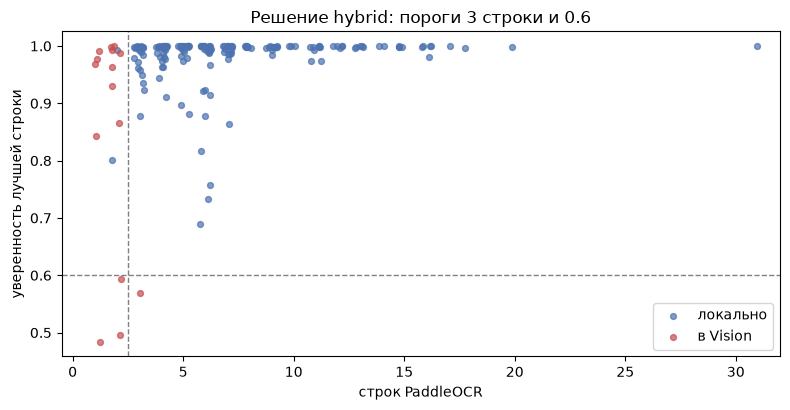

In [3]:
H = dumps['hybrid'].copy()
route = pd.json_normalize(H['ocr_route']).add_prefix('r_')
H = pd.concat([H.drop(columns=['ocr_route']), route], axis=1)
H['кадр'] = np.where(H.known, 'знакомое', 'незнакомое')
print('hybrid решил звать Vision:', int(H.r_cloud.sum()), 'из', len(H),
      '| Vision ответила:', int((H.r_cloud & ~H.r_fallback).sum()),
      '| откат на PaddleOCR (ошибка облака):', int(H.r_fallback.sum()))
if H.r_cloud.any() and H.r_fallback[H.r_cloud].all():
    print('ВНИМАНИЕ: ни один запрос Vision не прошёл — строки этих кадров прочитал PaddleOCR, '
          'и прогон hybrid по качеству совпадает с paddle. Проверьте YANDEX_OCR_API_KEY '
          '(роль ai.vision.user).')
why = H.r_reason.where(H.r_cloud, 'без облака').fillna('без облака')
display(pd.crosstab(why, H['кадр'], margins=True, margins_name='всего'))

fig, ax = plt.subplots(figsize=(8, 4.2))
for cloud, color, label in ((False, '#4C72B0', 'локально'), (True, '#C44E52', 'в Vision')):
    part = H[H.r_cloud == cloud]
    ax.scatter(part.r_local_lines + np.random.default_rng(0).uniform(-.25, .25, len(part)),
               part.r_local_conf_max, s=18, alpha=.7, color=color, label=label)
ax.axvline(2.5, color='grey', ls='--', lw=1); ax.axhline(0.6, color='grey', ls='--', lw=1)
ax.set(xlabel='строк PaddleOCR', ylabel='уверенность лучшей строки', xlim=(-0.5, min(40, H.r_local_lines.max() + 1)),
       title='Решение hybrid: пороги 3 строки и 0.6')
ax.legend(); plt.tight_layout(); plt.show()

### 2.1 Вина, ушедшие в облако, и что это изменило

Сравнение с прогоном `paddle` по тем же кадрам: исход (`verdict`) и ранг верного вина в
текстовой ветке (`txt_rank`, 0 — первое место; 1000000 — нет в списке).

In [4]:
P = dumps['paddle'].set_index('path')
H['исход paddle'] = H.path.map(P.verdict)
H['txt_rank paddle'] = H.path.map(P.txt_rank)
H['лучший paddle'] = H.path.map(P.best_id)
cloud = H[H.r_cloud].copy()

def change(row):
    if not row.known:
        before = row['исход paddle']; after = row.verdict
        return 'без изменений' if before == after else f'{before} → {after}'
    before = row['исход paddle'] == 'correct'; after = row.verdict == 'correct'
    return {(False, True): 'исправлено', (True, False): 'сломано'}.get((before, after), 'без изменений')

cloud['эффект'] = cloud.apply(change, axis=1)
print(cloud['эффект'].value_counts().to_string())
cols = ['wine_id', 'кадр', 'r_reason', 'r_local_lines', 'r_local_conf_max',
        'txt_rank paddle', 'txt_rank', 'исход paddle', 'verdict', 'эффект']
display(cloud.sort_values(['кадр', 'эффект', 'wine_id'])[cols]
        .rename(columns={'r_reason': 'почему', 'r_local_lines': 'строк', 'r_local_conf_max': 'conf',
                         'verdict': 'исход hybrid', 'txt_rank': 'txt_rank hybrid'})
        .reset_index(drop=True).round(2))

эффект
без изменений    15


,wine_id,кадр,почему,строк,conf,txt_rank paddle,txt_rank hybrid,исход paddle,исход hybrid,эффект
0,esse-kaberne-sovinon-krasnoe-suhoe-14,знакомое,low_conf,3,0.57,0,0,refused,refused,без изменений
1,shato-pino-dichkaberne-fran-krasnoe-suhoe-14,знакомое,few_lines,2,1.00,0,5,correct,correct,без изменений
2,shato-taman-bryut,знакомое,few_lines,2,0.99,0,0,correct,correct,без изменений
3,valeriy-zaharin-sandzhoveze-burlyuk-krasnoe-suhoe-13,знакомое,few_lines,1,0.99,8,9,correct,correct,без изменений
4,unknown-aya-purity-in-balance-2025,незнакомое,few_lines,2,0.93,1000000,1000000,refused,refused,без изменений
5,unknown-aya-purity-in-balance-2025,незнакомое,few_lines,2,0.87,1000000,1000000,refused,refused,без изменений
6,unknown-fanagoriya-classic-kaberne-suhoe,незнакомое,few_lines,2,0.96,1000000,1000000,refused,refused,без изменений
7,unknown-fanagoriya-classic-krasnoe-polusladkoe,незнакомое,few_lines,2,0.99,1000000,1000000,refused,refused,без изменений
8,unknown-golitsynskie-vina-polusladkoe-beloe,незнакомое,few_lines,2,0.59,1000000,1000000,refused,refused,без изменений
9,unknown-inkerman-vyberi-nastroenie-aligote-suhoe,незнакомое,few_lines,1,0.84,1000000,1000000,refused,refused,без изменений


In [5]:
# Изменения исхода на кадрах, которые в облако НЕ ходили, — это не эффект OCR, а шум
# (кроп и локальное чтение на стороне 1024 вместо 640: hybrid ужимает кадр меньше).
local = H[~H.r_cloud].copy()
local['эффект'] = local.apply(change, axis=1)
print('кадры без облака, изменения исхода:')
print(local['эффект'].value_counts().to_string())
display(local[local['эффект'] != 'без изменений'][['wine_id', 'кадр', 'исход paddle', 'verdict']])

кадры без облака, изменения исхода:
эффект
без изменений    180


,wine_id,кадр,исход paddle,verdict


## 3. VLM-судья: когда звался и помог ли

Отчёт судьи (`ScanResult.judge`) хранит причину вызова, выбор, что применено (`choose` /
`refuse` / `none`) и лидера до судьи (`before_id`). «Помог» для знакомого кадра — до судьи
ответ был неверным (или отказ), после — верный slug; «навредил» — наоборот. Для незнакомого
вина хороший исход — отказ.

In [6]:
V = dumps['hybrid+VLM'].copy()
judged = V[V.judge.notna()].copy()
J = pd.json_normalize(judged.judge.tolist()).set_index(judged.index)
judged = pd.concat([judged.drop(columns=['judge']), J], axis=1)
print('кадров:', len(V), ' вызовов судьи:', len(judged), ' ошибок провайдера:', int(judged.error.notna().sum()))
display(judged.error.fillna('ответ получен').value_counts().rename('вызовов').to_frame())

def judge_effect(row):
    if row.known:
        before = bool(row.before_answered) and row.before_id == row.true_id
        after = row.verdict == 'correct'
        top_before, top_after = row.before_id == row.true_id, row.best_id == row.true_id
        if before == after:
            return 'без изменений' + ('' if top_before == top_after else ' (сменился top-1)')
        return 'помог' if after else 'навредил'
    before, after = bool(row.before_answered), bool(row.answered)
    if before == after:
        return 'без изменений'
    return 'помог (отказ незнакомому)' if not after else 'навредил (принял незнакомое)'

judged['эффект'] = judged.apply(judge_effect, axis=1)
judged['кадр'] = np.where(judged.known, 'знакомое', 'незнакомое')
display(pd.crosstab([judged.reason, judged.applied], judged['эффект'], margins=True, margins_name='всего'))
display(pd.crosstab(judged.reason, judged['кадр'], margins=True, margins_name='всего'))

кадров: 195  вызовов судьи: 134  ошибок провайдера: 70


,вызовов
error,
yandex: ReadTimeout,70
ответ получен,64


эффект                  без изменений  навредил  навредил (принял незнакомое)  помог  помог (отказ незнакомому)  всего
reason         applied                                                                                                
refused_strong choose               0         0                             5     16                          0     21
               none                49         0                             0      0                          0     49
               refuse               1         0                             0      0                          0      1
same_family    choose              35         2                             0      4                          0     41
               none                21         0                             0      0                          0     21
               refuse               0         0                             0      0                          1      1
всего                             106         2                             5     20                          1    134

кадр,знакомое,незнакомое,всего
reason,,,
refused_strong,23,48,71
same_family,56,7,63
всего,79,55,134


In [7]:
known = judged[judged.known]
top1 = pd.DataFrame({
    'верный top-1 до судьи': [int((known.before_id == known.true_id).sum())],
    'верный top-1 после': [int((known.best_id == known.true_id).sum())],
    'верный ответ до': [int(((known.before_id == known.true_id) & known.before_answered.astype(bool)).sum())],
    'верный ответ после': [int((known.verdict == 'correct').sum())],
}, index=['знакомые кадры с судьёй'])
display(top1)

,верный top-1 до судьи,верный top-1 после,верный ответ до,верный ответ после
знакомые кадры с судьёй,67,72,48,66


### 3.1 Каждый вызов судьи

`before_id` — лидер решающего слоя, `best_id` — итог после судьи, `read_text` — что судья
прочитал на этикетке.

In [8]:
cols = ['wine_id', 'кадр', 'reason', 'applied', 'choice', 'confidence', 'before_id', 'best_id',
        'эффект', 'read_text', 'error']
changed = judged[~judged['эффект'].str.startswith('без изменений')]
print('вызовов, изменивших исход:', len(changed), 'из', len(judged))
with pd.option_context('display.max_rows', None):
    display(changed.sort_values(['эффект', 'reason', 'wine_id'])[cols].reset_index(drop=True).round(2))
# Таймауты: на каких кадрах судья не успел ответить.
timeouts = judged[judged.error.notna()]
display(pd.crosstab(timeouts.reason, timeouts['кадр'], margins=True, margins_name='всего'))

вызовов, изменивших исход: 28 из 134


,wine_id,кадр,reason,applied,choice,confidence,before_id,best_id,эффект,read_text,error
0,imenie-sikory-gerts-kaberne-sovinon-krasnoe-suhoe-14,знакомое,same_family,choose,2.0,0.95,imenie-sikory-gerts-kaberne-sovinon-krasnoe-suhoe-14,imenie-sikory-gerts-sikory-kaberne-sovinon-krasnoe-suhoe-14,навредил,СИМОРЫ ГЕРЦЪ Сикоры СЕМИГОРЬЕ 2022,NaN
1,imenie-sikory-gerts-kaberne-sovinon-krasnoe-suhoe-14,знакомое,same_family,choose,2.0,0.95,imenie-sikory-gerts-kaberne-sovinon-krasnoe-suhoe-14,imenie-sikory-gerts-sikory-kaberne-sovinon-krasnoe-suhoe-14,навредил,Sikory ГЕРЦЪ Сикоры СЕМИГОРЬЕ 2022,NaN
2,unknown-czimlyanskoe-beloe-polusuhoe,незнакомое,refused_strong,choose,1.0,1.00,czimlyanskoe-beloe-polusladkoe,czimlyanskoe-beloe-polusladkoe,навредил (принял незнакомое),ИГРИСТОЕ ВИНО ЦИМЛЯНСКОЕ Полусладкое Белое,NaN
3,unknown-solnechnaya-dolina-suhoe-beloe-krab,незнакомое,refused_strong,choose,6.0,1.00,solnechnaya-dolina-porto-solnechnoy-doliny-kokur-belyy-beloe-sladk...,beloe-suhoe,навредил (принял незнакомое),СОЛНЕЧНАЯ ДОЛИНА 1888 СУХОЕ БЕЛОЕ С ЗАЩИЩЕННЫМ ГЕОГРАФИЧЕСКИМ УКАЗ...,NaN
4,unknown-valeriy-zaharin-aligote-rezerv-avtorskoe,незнакомое,refused_strong,choose,4.0,1.00,valeriy-zaharin-avtorskoe-vino-ot-valeriya-zaharina-krasnoe-pino-n...,valeriy-zaharin-aligote-avtorskoe-valeriy-zaharin-beloe-bryut-115,навредил (принял незнакомое),ВАЛЕРИЙ ЗАХАРЬИН осн. 1994 АЛИГОТЕ РЕЗЕРВ АВТОРСКОЕ ВИНО С СОБСТВЕ...,NaN
5,unknown-valeriy-zaharin-muskat-avtorskoe,незнакомое,refused_strong,choose,1.0,0.95,valeriy-zaharin-muskat-valeriy-zaharin-muskat-ottonel-beloe-polusl...,valeriy-zaharin-muskat-valeriy-zaharin-muskat-ottonel-beloe-polusl...,навредил (принял незнакомое),ВАЛЕРИЙ ЗАХАРЬИН\nосн. 1994\nМУСКАТ\nАВТОРСКОЕ\nВИНО С СОБСТВЕННЫХ...,NaN
6,unknown-valeriy-zaharin-muskat-avtorskoe,незнакомое,refused_strong,choose,6.0,1.00,valeriy-zaharin-avtorskoe-vino-ot-valeriya-zaharina-krasnoe-pino-n...,valeriy-zaharin-muskat-valeriy-zaharin-muskat-ottonel-beloe-polusl...,навредил (принял незнакомое),ВАЛЕРИЙ ЗАХАРЬИН осн. 1994 МУСКАТ АВТОРСКОЕ ВИНО С СОБСТВЕННЫХ ВИН...,NaN
7,abrau-dyurso-imperatorskoe-bryut-shardone-beloe-12,знакомое,refused_strong,choose,2.0,1.00,abrau-dyurso-udelnoe-vedomstvo-imperatorskoe-beloe-bryut,abrau-dyurso-imperatorskoe-bryut-shardone-beloe-12,помог,ИМПЕРАТОРСКОЕ АБРАУ-ДЮРСО БРЮТ,NaN
8,chateau-de-talu-uroki-frantsuzskogo-kaberne-sovinon-krasnoe-suhoe-14,знакомое,refused_strong,choose,1.0,1.00,chateau-de-talu-uroki-frantsuzskogo-kaberne-sovinon-krasnoe-suhoe-14,chateau-de-talu-uroki-frantsuzskogo-kaberne-sovinon-krasnoe-suhoe-14,помог,ШАТО ДЕ ТАЛЮ УРОКИ ФРАНЦУЗСКОГО КАБЕРНЕ СОВИНЬОН ГЕЛЕНДЖИК,NaN
9,czimlyanskoe-beloe-polusladkoe,знакомое,refused_strong,choose,1.0,0.95,czimlyanskoe-beloe-polusladkoe,czimlyanskoe-beloe-polusladkoe,помог,ИГРИСТОЕ ВИНО ЦИМЛЯНСКОЕ Полусладкое Белое,NaN


кадр,знакомое,незнакомое,всего
reason,,,
refused_strong,7,42,49
same_family,19,2,21
всего,26,44,70


### 3.2 Судья и hybrid по отдельности

Прогон `hybrid+VLM` отличается от `hybrid` только судьёй, поэтому разница их исходов на
одних кадрах — чистый вклад судьи; сверка ниже проверяет, что вне вызовов судьи исходы совпали.

In [9]:
Hh = dumps['hybrid'].set_index('path')
V['исход hybrid'] = V.path.map(Hh.verdict)
diff = V[V['исход hybrid'] != V.verdict]
print('кадров с другим исходом:', len(diff), '; из них без вызова судьи:', int(diff.judge.isna().sum()))
display(diff[['wine_id', 'known', 'исход hybrid', 'verdict']].reset_index(drop=True))

кадров с другим исходом: 28 ; из них без вызова судьи: 0


,wine_id,known,исход hybrid,verdict
0,massandra-portveyn-krasnyy-alushta,True,refused,correct
1,massandra-portveyn-krasnyy-alushta,True,refused,correct
2,massandra-portveyn-krasnyy-alushta,True,refused,correct
3,massandra-portveyn-krasnyy-alushta,True,refused,correct
4,massandra-portveyn-belyy-krymskiy,True,twin,correct
5,massandra-portveyn-belyy-krymskiy,True,refused,correct
6,abrau-dyurso-imperatorskoe-bryut-shardone-beloe-12,True,refused,correct
7,abrau-dyurso-russkoe-igristoe-polusuhoe-rozovoe-pino-nuar-12,True,twin,correct
8,chateau-de-talu-uroki-frantsuzskogo-kaberne-sovinon-krasnoe-suhoe-14,True,twin,correct
9,chateau-de-talu-uroki-frantsuzskogo-kaberne-sovinon-krasnoe-suhoe-14,True,refused,correct


## 4. Выводы (24.09.2026, прогоны `cloud-07`, git f540726 + маршруты OCR)

**Что включено в сервисе.** `.env`: `WINE_OCR=paddle`, `WINE_VLM=0` — облако в распознавании не
используется. Цифры ниже — что дало бы включение. Тест — holdout: правила вызова судьи и
пороги hybrid **нельзя** подбирать по этим цифрам; любые изменения проверяются на train/живых
кадрах, а тест прогоняется один раз после.

**Ключи.** `YANDEX_OCR_API_KEY` из `.env` Vision отклоняет (HTTP 401 «Unknown api key»); прогоны
сделаны с ключом AI Studio (`YANDEX_LLM_API_KEY`), он Vision принимает. Без исправления ключа
hybrid в сервисе молча откатывается на PaddleOCR на каждом «слабом» кадре.

**Hybrid OCR — не помогает на этом тесте.** Vision позвали на 15 кадрах из 195 (14 `few_lines`,
1 `low_conf`): 4 знакомых и 11 незнакомых. Vision ответила на все 15, исход не изменился ни на
одном кадре. У трёх из четырёх знакомых PaddleOCR и так ставил верное вино первым в текстовой
ветке (`txt_rank` 0); на `shato-pino-dichkaberne-fran` облачный текст ухудшил ранг 0 → 5, ответ
остался верным. Слабое чтение бывает в основном у незнакомых вин, где текст всё равно не
найдёт карточку.

**VLM-судья — большой выигрыш на знакомых, но с оговорками.**

- Звался на 134 кадрах из 195 (69 %): `refused_strong` 71 (23 знакомых, 48 незнакомых),
  `same_family` 63 (56 / 7), `margin` — ни разу (проверяется после `same_family`).
- Задержка: p50 8.4 с, p95 15.2 с на вызов; итог запроса p50 1.7 → 9.8 с. При стандартном
  таймауте 4 с отваливались 135 вызовов из 136, поэтому прогон — с `WINE_VLM_TIMEOUT=15`, и даже
  так **70 из 134 вызовов (52 %) — таймаут**. Таймаут оставляет ответ пайплайна как есть.
- Итог на знакомых: верных ответов 62 → **80 из 93**, верный top-1 81 → 86, отказов 23 → 7,
  неверных 8 → 6. Помог на 20 знакомых кадрах, навредил на 2 (`imenie-sikory-gerts`: судья
  перевёл верный ответ на соседнюю карточку «Сикоры» той же винодельни).
- Цена — незнакомые вина: ложные приёмы 0.069 → 0.108 (7 → 11 из 102). Все 5 новых ложных
  приёмов — `refused_strong` на незнакомом вине, где судья выбрал близнеца той же винодельни
  (Цимлянское полусухое → полусладкое, Захарьин Алиготе/Мускат «авторское» → другие позиции
  Захарьина) с уверенностью 1.0. Один раз судья, наоборот, верно отказал (Кагор Партенит).
- Все 11 ошибок знакомых вин, оставшихся после судьи, — кадры, где судья звался, но не успел
  ответить. Потенциал на знакомых больше измеренного.
- **Главный риск:** из 48 вызовов `refused_strong` на незнакомых 42 закончились таймаутом. Из 6,
  где судья успел ответить, в 5 он принял чужое вино. Если таймауты починить, ложных приёмов
  станет заметно больше, чем 0.108. Уверенность судьи не калибрована: 54 ответа из 64 — ровно
  1.0, остальные 0.95; «ни одна не подходит» он выбрал 2 раза из 64.

**Что делать (решения — не по этому тесту).**
1. Исправить `YANDEX_OCR_API_KEY` (роль `ai.vision.user`) или не включать hybrid: на тесте
   он ничего не меняет, а добавляет облачный запрос на ~8 % кадров.
2. Для проверки заказчика (ответ на каждом кадре, незнакомых нет) судья — самый сильный
   рычаг из измеренных. Для продукта `refused_strong` в нынешнем виде опасен: судья почти
   никогда не говорит «ни одна». Кандидаты на проверку на train/живых кадрах: звать судью
   только на `same_family`, требовать совпадения `read_text` с названием выбранной карточки,
   ограничить подъём вероятности при `refused_strong`.
3. Задержка: 8–15 с на вызов на 69 % кадров неприемлема для `/scan`; нужен либо более быстрый
   провайдер или модель, либо асинхронный судья, либо вызов реже.